In [16]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
from matplotlib import rcParams
rcParams['font.family'] = 'Arial'
rcParams['pdf.fonttype'] = 42  # Use TrueType fonts
rcParams['axes.linewidth'] = 0.5
rcParams['xtick.major.width'] = 0.5
rcParams['ytick.major.width'] = 0.5
rcParams['savefig.dpi'] = 300  # Ensure a high resolution

In [18]:
from catrace.run.run_average_timecourse import run_average_timecourse, RunAverageTimecourseParams


## Dp

2021-07-15-DpOBEM-N2_Dp None
2021-07-16-DpOBEM-N3_Dp None
2021-12-10-DpOBEM-N4_Dp None


/tungstenfs/scratch/gfriedri/hubo/Software/python_env/catrace_cpu/lib/python3.10/site-packages/dataclasses_json/core.py:188: RuntimeWarning: 'NoneType' object value of non-optional type odors_learned detected when decoding DatasetConfig.
  warnings.warn(
/tungstenfs/scratch/gfriedri/hubo/Software/python_env/catrace_cpu/lib/python3.10/site-packages/dataclasses_json/core.py:188: RuntimeWarning: 'NoneType' object value of non-optional type odors_novel detected when decoding DatasetConfig.
  warnings.warn(
/tungstenfs/scratch/gfriedri/hubo/Software/python_env/catrace_cpu/lib/python3.10/site-packages/dataclasses_json/core.py:188: RuntimeWarning: 'NoneType' object value of non-optional type onsets detected when decoding DatasetConfig.
  warnings.warn(


2021-12-31-DpOBEM-N7_Dp None
2022-02-13-DpOBEM-N10_Dp None
2022-02-20-DpOBEM-N11_Dp None
2021-02-05-DpOBEM-JH9_Dp None
2021-03-18-DpOBEM-JH10_Dp None
2021-03-19-DpOBEM-JH10_Dp None
2021-04-02-DpOBEM-JH11_Dp None
2021-04-03-DpOBEM-JH11_Dp None
2021-05-01-DpOBEM-JH13_Dp None
2021-05-22-DpOBEM-JH14_Dp None
2021-09-15-DpOBEM-JH20_Dp None
2021-09-17-DpOBEM-JH20_Dp None
2021-09-18-DpOBEM-JH20_Dp None
2021-07-30-DpOBEM-JH17_Dp None
2021-07-31-DpOBEM-JH17_Dp None
2021-09-02-DpOBEM-JH18_Dp None
2021-09-03-DpOBEM-JH18_Dp None
2021-09-04-DpOBEM-JH18_Dp None
2021-09-29-DpOBEM-JH21_Dp None
2021-10-01-DpOBEM-JH21_Dp None
2021-10-02-DpOBEM-JH21_Dp None
2021-10-14-DpOBEM-JH22_Dp None
2021-11-10-DpOBEM-JH23_Dp None
2021-11-11-DpOBEM-JH23_Dp None
2021-11-14-DpOBEM-JH23_Dp None
2021-11-24-DpOBEM-JH24_Dp None
2021-11-27-DpOBEM-JH24_Dp None
2021-11-26-DpOBEM-JH24_Dp None


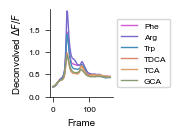

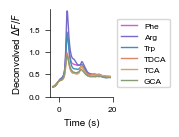

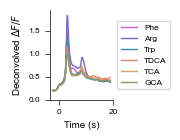

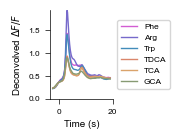

In [19]:
params = RunAverageTimecourseParams(
    config_file = '../juvenile_dataset_without14mm_phearg.json',
    assembly_name = '',
    do_plot_per_fish = False,
    #dff = dff,
    figsize=(1.9, 1.5),
    cut_time=2.3,
    odor_colors = ['#d25dd2', '#766acb', '#428cba', '#da866b', '#daa36b', '#879a73'],
    ylim=(0, 1.95), # (0, 0.26),
    label_fontsize=7,
    tick_label_fontsize=6,
    legend_fontsize=6,
    convert_to_rate=False, # The data is already in rate
)

if params.assembly_name == '':
    assembly_label = 'all_neurons'
else:
    assembly_label = params.assembly_name

dff, outfigs = run_average_timecourse(params)

In [20]:
dff.xs('naive', level='condition', axis=1).shape
dff.shape

(2898, 43211)

In [21]:
import numpy as np
odor_time_range = [2, 7]
frame_rate = 7.5
manifold_time_range = np.array([38, 63]) /frame_rate - params.cut_time
print(manifold_time_range)



[2.76666667 6.1       ]


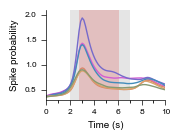

In [22]:
import matplotlib.patches as patches

def add_time_range_rectangle(ax, time_range, color='gray', alpha=0.6, text=None, fontsize=6, text_offset=0.02):
    # Retrieve the current y-limits of the axes
    ylim = ax.get_ylim()
    
    # Create a rectangle that spans from ylim[0] to ylim[1]
    rect = patches.Rectangle(
        (time_range[0], ylim[0]),
        width=time_range[1] - time_range[0],
        height=ylim[1] - ylim[0],
        color=color,
        alpha=alpha,
        linewidth=0
    )
    ax.add_patch(rect)
    
    if text is not None:
        # Place the text at the center of the rectangle
        ax.text(
            x=time_range[0] + (time_range[1] - time_range[0]) / 2,
            y=ylim[1] + text_offset,
            s=text,
            ha='center',
            va='center',
            color=color,
            fontsize=fontsize
        )



for name in ['fig_time', 'fig_naive_time', 'fig_trained_time']:
    fig = outfigs[name]
    ax = fig.get_axes()[0]
    ax.set_xlim([0, 10])
    ax.set_ylim([0.3, 2.1])#[0.02, 0.28])
    # Set xticks with interval of 2.5 using multiplelocator
    from matplotlib.ticker import MultipleLocator
    ax.xaxis.set_major_locator(MultipleLocator(2))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    # Set ylabel
    ylabel = 'Spike rate (Hz)' if params.convert_to_rate else 'Spike probability'
    ax.set_ylabel(ylabel)
    # Remove legend
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    # Add rectangle for odor presentation
    add_time_range_rectangle(ax, odor_time_range, color='gray', alpha=0.2)#, text='Odor', fontsize=6, text_offset=0.03)
    # Add rectangle for manifold presentation
    add_time_range_rectangle(ax, manifold_time_range, color='tab:red', alpha=0.2)#, text='Used for analysis', fontsize=6, text_offset=0.06)
    # Tight layout
    fig.tight_layout()




from catrace.for_paper import save_figure_for_paper
paper_fig_dir = '/tungstenfs/scratch/gfriedri/hubo/Dp_manifold/figures_for_paper'
dataset_name = 'juvenile'
save_figure_for_paper(outfigs['fig_time'], f'{dataset_name}_timecourse', paper_fig_dir)
save_figure_for_paper(outfigs['fig_naive_time'], f'{dataset_name}_timecourse_naive', paper_fig_dir)
save_figure_for_paper(outfigs['fig_trained_time'], f'{dataset_name}_timecourse_trained', paper_fig_dir)
outfigs['fig_trained_time']

/tungstenfs/scratch/gfriedri/hubo/Software/python_env/catrace_cpu/lib/python3.10/site-packages/dataclasses_json/core.py:188: RuntimeWarning: 'NoneType' object value of non-optional type odors_learned detected when decoding DatasetConfig.
  warnings.warn(
/tungstenfs/scratch/gfriedri/hubo/Software/python_env/catrace_cpu/lib/python3.10/site-packages/dataclasses_json/core.py:188: RuntimeWarning: 'NoneType' object value of non-optional type odors_novel detected when decoding DatasetConfig.
  warnings.warn(
/tungstenfs/scratch/gfriedri/hubo/Software/python_env/catrace_cpu/lib/python3.10/site-packages/dataclasses_json/core.py:188: RuntimeWarning: 'NoneType' object value of non-optional type onsets detected when decoding DatasetConfig.
  warnings.warn(


2021-07-15-DpOBEM-N2_OB None
2021-07-16-DpOBEM-N3_OB None
2021-12-10-DpOBEM-N4_OB None
2021-12-31-DpOBEM-N7_OB None
2022-02-13-DpOBEM-N10_OB None
2022-02-20-DpOBEM-N11_OB None
2021-02-05-DpOBEM-JH9_OB None
2021-03-18-DpOBEM-JH10_OB None
2021-03-19-DpOBEM-JH10_OB None
2021-04-02-DpOBEM-JH11_OB None
2021-04-03-DpOBEM-JH11_OB None
2021-05-01-DpOBEM-JH13_OB None
2021-05-22-DpOBEM-JH14_OB None
2021-09-15-DpOBEM-JH20_OB None
2021-09-17-DpOBEM-JH20_OB None
2021-09-18-DpOBEM-JH20_OB None
2021-07-30-DpOBEM-JH17_OB None
2021-07-31-DpOBEM-JH17_OB None
2021-09-02-DpOBEM-JH18_OB None
2021-09-03-DpOBEM-JH18_OB None
2021-09-04-DpOBEM-JH18_OB None
2021-09-29-DpOBEM-JH21_OB None
2021-10-01-DpOBEM-JH21_OB None
2021-10-02-DpOBEM-JH21_OB None
2021-10-14-DpOBEM-JH22_OB None
2021-11-10-DpOBEM-JH23_OB None
2021-11-11-DpOBEM-JH23_OB None
2021-11-14-DpOBEM-JH23_OB None
2021-11-24-DpOBEM-JH24_OB None
2021-11-27-DpOBEM-JH24_OB None
2021-11-26-DpOBEM-JH24_OB None


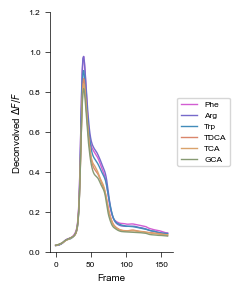

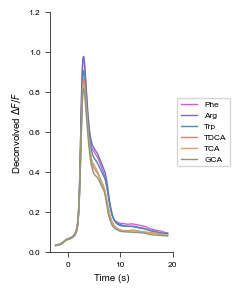

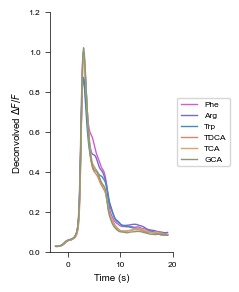

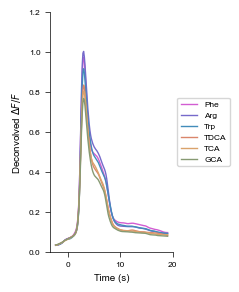

In [23]:
params = RunAverageTimecourseParams(
    config_file = '../olfactory_bulb/juvenile_dataset_OB_without14mm_phearg.json',
    assembly_name = '',
    do_plot_per_fish = False,
    #dff = ob_dff,
    figsize=(2.5, 3),
    cut_time=2.3,
    odor_colors = ['#d25dd2', '#766acb', '#428cba', '#da866b', '#daa36b', '#879a73'],
    ylim=(0, 1.2)
)

if params.assembly_name == '':
    assembly_label = 'all_neurons'
else:
    assembly_label = params.assembly_name

ob_dff, ob_outfigs = run_average_timecourse(params)

In [24]:
dff
# Number of neurons:
print('Dp')
print(dff.shape[1])
print('OB')
print(ob_dff.shape[1])

Dp
43211
OB
32070


In [25]:
def stack_dff(dff):
    dff_stacked = dff.T.groupby(level='fish_id').mean().T.groupby(level=['odor', 'time']).mean().T.stack('odor')
    # Remove the index
    dff_stacked = dff_stacked.reset_index()
    # Remove columns of fish_id and odor
    dff_stacked = dff_stacked.drop(columns=['fish_id', 'odor']).T
    return dff_stacked

condition_tag = 'naive'

def select_condition(dff, condition_tag):
    if condition_tag == 'all':
        return dff
    dff_condition = dff.xs(condition_tag, level='condition', axis=1)
    return dff_condition

dff_condition = select_condition(dff, condition_tag)
ob_dff_condition = select_condition(ob_dff, condition_tag)

dff_stacked = stack_dff(dff_condition)
ob_dff_stacked = stack_dff(ob_dff_condition)
ob_dff_stacked

/tmp/ipykernel_2397386/1066814268.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dff_stacked = dff.T.groupby(level='fish_id').mean().T.groupby(level=['odor', 'time']).mean().T.stack('odor')
/tmp/ipykernel_2397386/1066814268.py:2: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  dff_stacked = dff.T.groupby(level='fish_id').mean().T.groupby(level=['odor', 'time']).mean().T.stack('odor')
/tmp/ipykernel_2397386/1066814268.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior o

,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
time,,,,,,,,,,,,,,,,,,,,,
0,0.024817,0.027584,0.023761,0.025663,0.025684,0.026174,0.028202,0.028916,0.029886,0.030417,...,0.024532,0.027734,0.028019,0.022445,0.024307,0.025292,0.026052,0.025975,0.025946,0.024221
1,0.025247,0.026042,0.024295,0.026163,0.025800,0.026238,0.028205,0.028606,0.029339,0.029447,...,0.023501,0.025703,0.026486,0.022258,0.023998,0.024751,0.026075,0.025350,0.026043,0.024400
2,0.026269,0.025334,0.025253,0.027373,0.026341,0.027094,0.028515,0.028621,0.029541,0.029393,...,0.023061,0.024655,0.025349,0.022462,0.024121,0.024713,0.026329,0.024779,0.026443,0.024507
3,0.027144,0.025441,0.025978,0.029480,0.026898,0.027457,0.029355,0.028462,0.029691,0.029158,...,0.023031,0.024419,0.024434,0.023000,0.024266,0.024170,0.026766,0.024637,0.026791,0.024560
4,0.028055,0.025747,0.026827,0.031973,0.027740,0.027465,0.030503,0.028356,0.029747,0.029117,...,0.023185,0.024472,0.023967,0.023229,0.024455,0.023431,0.026853,0.025113,0.026934,0.024617
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,0.094660,0.145116,0.065809,0.078475,0.073631,0.053408,0.074747,0.098774,0.062649,0.077545,...,0.084551,0.072401,0.089214,0.075675,0.072719,0.070181,0.088765,0.082775,0.093949,0.101766
157,0.091785,0.144878,0.066159,0.079961,0.073269,0.052890,0.073100,0.099916,0.062533,0.079793,...,0.083400,0.074408,0.089476,0.075750,0.070950,0.069493,0.091088,0.084684,0.091735,0.101802
158,0.089848,0.143682,0.065674,0.080727,0.071605,0.052987,0.071859,0.102233,0.062415,0.082905,...,0.083142,0.075459,0.090989,0.076018,0.069712,0.069521,0.092627,0.085992,0.090653,0.100815


In [26]:
def put_legend_outside_plot(ax, legend_fontsize=6):
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), prop={'size': legend_fontsize})

In [27]:
cut_time = 2.3 # seconds
frame_rate = 7.5
cut_frame = int(cut_time * frame_rate)
total_time = 10
total_frame = int(total_time * frame_rate)
frame_range = (cut_frame, cut_frame + total_frame)
frame_range

(17, 92)

In [28]:
from catrace.process_time_trace import shift_timepoints

def cutout_dff(dff, cut_frame, total_frame):
    dff_cutout = shift_timepoints(dff, cut_frame)
    dff_cutout = dff_cutout.iloc[0:total_frame]
    return dff_cutout

dff_cutout = cutout_dff(dff_stacked, cut_frame, total_frame)
ob_dff_cutout = cutout_dff(ob_dff_stacked, cut_frame, total_frame)

In [29]:
dff_cutout

,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
time,,,,,,,,,,,,,,,,,,,,,
0,0.276805,0.287800,0.319786,0.238028,0.262245,0.251553,0.272222,0.265899,0.245422,0.252666,...,0.285214,0.289958,0.290746,0.323202,0.339760,0.349608,0.327632,0.334650,0.326392,0.325987
1,0.281697,0.299327,0.323223,0.239072,0.272451,0.255772,0.283430,0.275586,0.256027,0.254106,...,0.298510,0.302539,0.292011,0.323548,0.347079,0.351426,0.334372,0.333706,0.328401,0.328196
2,0.284508,0.304589,0.322654,0.239886,0.280429,0.256881,0.293365,0.280505,0.265002,0.254816,...,0.309836,0.307511,0.294663,0.321354,0.348209,0.353593,0.337828,0.335639,0.327416,0.326496
3,0.296792,0.305911,0.323774,0.238232,0.284560,0.257959,0.298459,0.284837,0.273546,0.256891,...,0.320619,0.310881,0.297833,0.320357,0.348519,0.354668,0.338782,0.336269,0.328318,0.325170
4,0.318534,0.309639,0.328067,0.242127,0.285253,0.256218,0.299172,0.290485,0.278720,0.258367,...,0.326311,0.312260,0.301514,0.324681,0.346648,0.354886,0.339133,0.339281,0.329638,0.325957
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,0.841480,1.037895,0.685946,0.719276,0.575834,0.500345,0.553427,0.734271,0.375506,0.516676,...,0.698897,0.746187,0.699734,0.641171,0.326068,0.637856,0.410774,0.395359,0.341645,0.344173
71,0.815630,1.007915,0.677452,0.686442,0.580577,0.467361,0.558549,0.707030,0.374710,0.496066,...,0.707533,0.746601,0.685393,0.654684,0.321973,0.577846,0.398219,0.415046,0.342010,0.348516
72,0.778670,0.960353,0.672099,0.653234,0.579835,0.435749,0.573730,0.680107,0.373587,0.481827,...,0.715999,0.742830,0.668267,0.659380,0.321517,0.538060,0.386898,0.434160,0.347460,0.352079


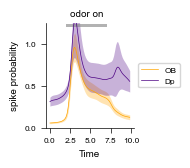

In [30]:
import matplotlib.pyplot as plt
from catrace.plot_trace import plot_mean_with_std
figsize=(2, 1.8)
tick_fontsize = 6
label_fontsize = 7
linewidth = 0.5

# Step 4: Prepare the plot
fig, ax = plt.subplots(figsize=figsize)

# Plot normalized OB region using the custom function
plot_mean_with_std(ob_dff_cutout, frame_rate=7.5, ax=ax, color='orange', label='OB', linewidth=linewidth)

# Plot normalized Dp region using the custom function
plot_mean_with_std(dff_cutout, frame_rate=7.5, ax=ax, color='indigo', label='Dp', linewidth=linewidth)

# Final touches
# ax.set_title('Normalized Time Course of OB and Dp Regions')
# ax.set_ylabel('Deconvolved $\Delta F/F_0$', fontsize=label_fontsize)
ax.set_ylabel('spike probability', fontsize=label_fontsize)
ax.set_xlabel('Time', fontsize=label_fontsize)
# ax.legend(title='Region', fontsize=16, title_fontsize=16)
put_legend_outside_plot(ax, legend_fontsize=tick_fontsize)
# Set yticks fontsize
ax.tick_params(labelsize=tick_fontsize)

ax.set_ylim([0, 1.25])
from catrace.visualize import set_yticks_interval
set_yticks_interval(ax, 0.5)

# Set xticks with interval of 2.5 using multiplelocator
from matplotlib.ticker import MultipleLocator
ax.xaxis.set_major_locator(MultipleLocator(2.5))

# Plot a gray bar from x = 2 to x = 7
# ax.axvspan(2, 7, color='gray', alpha=0.1)
import matplotlib.patches as patches
rect = patches.Rectangle((2, 1.2), width=5, height=0.03, color='gray', alpha=0.6,
        linewidth=0)
ax.text(x=2 + 5/2, y=1.2+0.1, s="odor on", ha='center', va='bottom', color='black', fontsize=label_fontsize)
ax.add_patch(rect)

import seaborn as sns
sns.despine()

fig.tight_layout()

from catrace.for_paper import save_figure_for_paper
paper_fig_dir = '/tungstenfs/scratch/gfriedri/hubo/Dp_manifold/figures_for_paper'
dataset_name = 'juvenile'
fig_name = f'{dataset_name}_timecourse_ob_dp_{condition_tag}'
save_figure_for_paper(fig, fig_name, paper_fig_dir)

# Make the figure only contains core plots
def remove_text_elements(fig):
    ax = fig.get_axes()[0]
    # Remove all the axis labels
    ax.set_xlabel('')
    ax.set_ylabel('')
    # Remove the legend
    ax.legend().remove()
    # Remove x, y ticks
    ax.set_xticks([])
    ax.set_yticks([])

#fig_no_text = remove_text_elements(fig)
#fig_no_text_name = f'{dataset_name}_timecourse_ob_dp_{condition_tag}_no_text'
#save_figure_for_paper(fig, fig_no_text_name, paper_fig_dir)
    